# Medicine Price & Generic Alternative Finder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
df = pd.read_csv("../data/original.csv")

### Exploring the Dataset

In [3]:
df.head()

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,False,tablet,5.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 5 tablets,Alembic Pharmaceuticals Ltd
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,False,syrup,100.0,bottle,2,Ambroxol,30mg/5ml,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",bronchodilator,bottle of 100 ml Syrup,Glenmark Pharmaceuticals Ltd
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,False,tablet,10.0,strip,1,Fexofenadine,120mg,"[{'name': 'Fexofenadine', 'strength': '120mg',...",antihistamine,strip of 10 tablets,Sanofi India Ltd
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,False,tablet,15.0,strip,1,Pheniramine,25mg,"[{'name': 'Pheniramine', 'strength': '25mg', '...",other,strip of 15 tablets,Sanofi India Ltd


In [4]:
df.shape

(253973, 15)

In [5]:
df.columns

Index(['product_id', 'brand_name', 'manufacturer', 'price_inr',
       'is_discontinued', 'dosage_form', 'pack_size', 'pack_unit',
       'num_active_ingredients', 'primary_ingredient', 'primary_strength',
       'active_ingredients', 'therapeutic_class', 'packaging_raw',
       'manufacturer_raw'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253973 entries, 0 to 253972
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product_id              253973 non-null  int64  
 1   brand_name              253973 non-null  str    
 2   manufacturer            253973 non-null  str    
 3   price_inr               253973 non-null  float64
 4   is_discontinued         253973 non-null  bool   
 5   dosage_form             253973 non-null  str    
 6   pack_size               231643 non-null  float64
 7   pack_unit               231643 non-null  str    
 8   num_active_ingredients  253973 non-null  int64  
 9   primary_ingredient      253973 non-null  str    
 10  primary_strength        228775 non-null  str    
 11  active_ingredients      253973 non-null  str    
 12  therapeutic_class       253973 non-null  str    
 13  packaging_raw           253973 non-null  str    
 14  manufacturer_raw        253973 

In [7]:
df.isnull().sum()

product_id                    0
brand_name                    0
manufacturer                  0
price_inr                     0
is_discontinued               0
dosage_form                   0
pack_size                 22330
pack_unit                 22330
num_active_ingredients        0
primary_ingredient            0
primary_strength          25198
active_ingredients            0
therapeutic_class             0
packaging_raw                 0
manufacturer_raw              0
dtype: int64

In [8]:
df.describe()

,product_id,price_inr,pack_size,num_active_ingredients
count,253973.000000,253973.000000,231643.000000,253973.000000
mean,126987.000000,270.530844,18.988871,1.441893
std,73315.834296,3029.584134,36.717320,0.496795
min,1.000000,0.000000,1.000000,1.000000
25%,63494.000000,48.000000,10.000000,1.000000
50%,126987.000000,79.000000,10.000000,1.000000
75%,190480.000000,140.000000,10.000000,2.000000
max,253973.000000,436000.000000,5000.000000,5.000000


In [9]:
df.sample(5)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
33508,33509,Btpod 50mg Oral Suspension,Biotanic Lifesciences,78.00,False,suspension,30.0,bottle,1,Cefpodoxime Proxetil,50mg,"[{'name': 'Cefpodoxime Proxetil', 'strength': ...",other,bottle of 30 ml Oral Suspension,Biotanic Lifesciences
44391,44392,Cloviral 200mg Tablet DT,Sumac Pharma Pvt Ltd,63.75,False,tablet,10.0,strip,1,Acyclovir,200mg,"[{'name': 'Acyclovir', 'strength': '200mg', 'f...",other,strip of 10 tablet dt,Sumac Pharma Pvt Ltd
148723,148724,Metshine 2mg/500mg Tablet,Alexa Organics Private Limited,143.00,False,tablet,10.0,strip,2,Glimepiride,2mg,"[{'name': 'Glimepiride', 'strength': '2mg', 'f...",antidiabetic,strip of 10 tablets,Alexa Organics Private Limited
143104,143105,Mupicol 2% Ointment,Hi-Cure Biotech,99.00,False,ointment,5.0,tube,1,Mupirocin,NaN,"[{'name': 'Mupirocin', 'strength': None, 'full...",other,tube of 5 gm Ointment,Hi-Cure Biotech
133454,133455,Metrogyl DG Forte Gel,J B Chemicals and Pharmaceuticals Ltd,68.00,False,gel,20.0,tube,2,Chlorhexidine Gluconate,NaN,"[{'name': 'Chlorhexidine Gluconate', 'strength...",other,tube of 20 gm Dental Gel,J B Chemicals and Pharmaceuticals Ltd


### Observations:

- Dataset size: 253973
- Max Price: 436000
- Min Price: 0
- Missing values:
  - pack_size:  22330
  - pack_unit:  22330
  - primary_strength:  25198

### Analysing the Data

In [10]:
df["manufacturer"].value_counts()

manufacturer
Sun Pharmaceutical Industries Ltd       2986
Cipla Ltd                               2467
Intas Pharmaceuticals Ltd               2302
Torrent Pharmaceuticals Ltd             2027
Alkem Laboratories Ltd                  1809
                                        ... 
Zeochem Pharmaceuticals Pvt Ltd            1
Unisearch Laboratories India Pvt Ltd       1
AllKind Healthcare                         1
Bliss Life Pharmaceuticals                 1
Anamiva Life Sciences                      1
Name: count, Length: 7648, dtype: int64

In [11]:
df["price_inr"].describe()

count    253973.000000
mean        270.530844
std        3029.584134
min           0.000000
25%          48.000000
50%          79.000000
75%         140.000000
max      436000.000000
Name: price_inr, dtype: float64

In [12]:
df[df["price_inr"] == df["price_inr"].max()]

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
113862,113863,Imbruvica 140mg Capsule,Janssen Pharmaceuticals,436000.0,False,capsule,120.0,units,1,Ibrutinib,140mg,"[{'name': 'Ibrutinib', 'strength': '140mg', 'f...",other,bottle of 120 capsules,Janssen Pharmaceuticals


In [13]:
df[df["price_inr"] == df["price_inr"].min()]

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
35090,35091,Covishield Vaccine,Serum Institute Of India Ltd,0.0,False,injection,5.0,ml,1,ChAdOx1 nCoV-19 Corona Virus Vaccine,NaN,[{'name': 'ChAdOx1 nCoV-19 Corona Virus Vaccin...,other,vial of 5 ml Solution for Injection,Serum Institute Of India Ltd
37004,37005,Covaxin Vaccine,Bharat Biotech,0.0,False,injection,10.0,ml,2,Whole Virion,NaN,"[{'name': 'Whole Virion', 'strength': None, 'f...",other,vial of 10 ml Solution for Injection,Bharat Biotech
141999,142000,Moderna Vaccine,"ModernaTX, Inc",0.0,False,injection,5.0,ml,1,Messenger ribonucleic acid,NaN,"[{'name': 'Messenger ribonucleic acid', 'stren...",other,vial of 5 ml Solution for Injection,"ModernaTX, Inc"
204460,204461,Sputnik V Vaccine,Dr Reddy's Laboratories Ltd,0.0,False,injection,5.0,ml,1,Human adenovirus vector vaccine,NaN,"[{'name': 'Human adenovirus vector vaccine', '...",other,vial of 0.5 ml Injection,Dr Reddy's Laboratories Ltd


In [14]:
df["active_ingredients"].value_counts().head(10)

active_ingredients
[{'name': 'Aceclofenac', 'strength': '100mg', 'full_description': 'Aceclofenac (100mg)'}, {'name': 'Paracetamol', 'strength': '325mg', 'full_description': 'Paracetamol (325mg)'}]             4679
[{'name': 'Pantoprazole', 'strength': '40mg', 'full_description': 'Pantoprazole (40mg)'}]                                                                                                      2643
[{'name': 'Domperidone', 'strength': '30mg', 'full_description': 'Domperidone (30mg)'}, {'name': 'Rabeprazole', 'strength': '20mg', 'full_description': 'Rabeprazole (20mg)'}]                 2617
[{'name': 'Levocetirizine', 'strength': '5mg', 'full_description': 'Levocetirizine (5mg)'}, {'name': 'Montelukast', 'strength': '10mg', 'full_description': 'Montelukast (10mg)'}]             2284
[{'name': 'Rabeprazole', 'strength': '20mg', 'full_description': 'Rabeprazole (20mg)'}]                                                                                                        2101
[

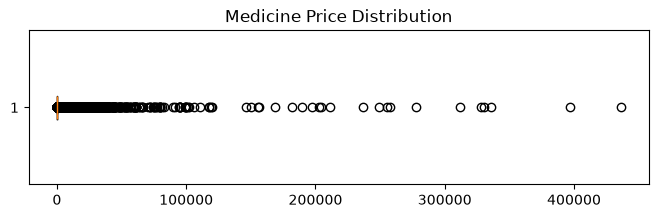

In [15]:
plt.figure(figsize=(8,2))

plt.boxplot(df["price_inr"], orientation="horizontal")

plt.title("Medicine Price Distribution")

plt.show()

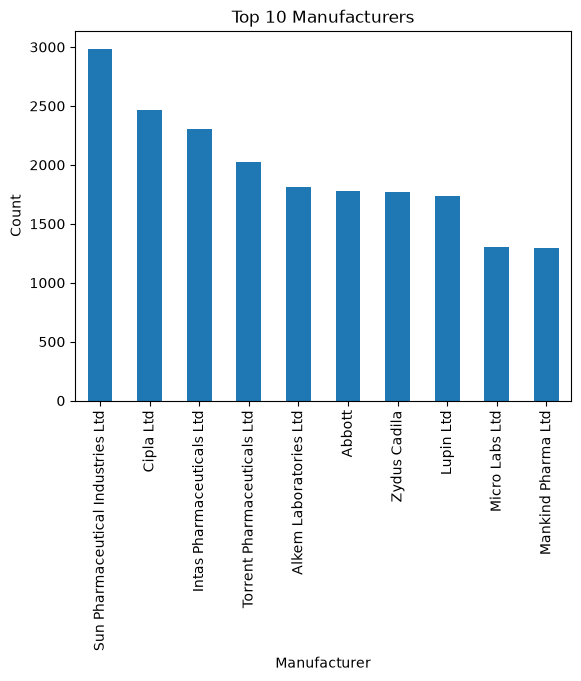

In [16]:
top = df["manufacturer"].value_counts().head(10)
top.plot(kind="bar")
plt.xlabel("Manufacturer")
plt.ylabel("Count")
plt.title("Top 10 Manufacturers")
plt.show()


In [17]:
df["price_inr"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25      48.00
0.50      79.00
0.75     140.00
0.90     254.00
0.95     430.50
0.99    2899.28
Name: price_inr, dtype: float64

In [18]:
df.nlargest(50, "price_inr")[["brand_name", "price_inr", "manufacturer"]]

,brand_name,price_inr,manufacturer
113862,Imbruvica 140mg Capsule,436000.00,Janssen Pharmaceuticals
217021,Tecentriq 1200mg Injection,396725.00,Roche Products India Pvt Ltd
243971,Xtandi 40mg Soft Capsule,335635.00,Astellas Pharma Inc
28711,Besponsa 1mg Injection,330000.00,Pfizer Ltd
113861,Imbruvica 140mg Capsule,328000.00,Janssen Pharmaceuticals
129170,Lorbriqua 100mg Tablet,312000.00,Pfizer Ltd
219482,Tecentriq Injection,277708.00,Roche Products India Pvt Ltd
35994,Cyramza 500mg Injection,257532.00,Eli Lilly and Company India Pvt Ltd
175276,Perjeta 420mg Injection,255150.00,Roche Products India Pvt Ltd
116435,Kadcyla 160mg Injection,248937.00,Roche Products India Pvt Ltd


### Observations:

- Most common manufacturer: Sun Pharma
- Most common active ingredient: Aceclophenac (Paracetamol)
- Average medicine price: 270
- 99% medicines are priced below 2899
- Expensive outliers: All of them are justified

### Data Cleaning

In [19]:
clean_df = df.copy()

In [20]:
clean_df = clean_df.drop(columns=["product_id", "packaging_raw", "manufacturer_raw"])

In [21]:
clean_df.duplicated().sum()

np.int64(9)

In [22]:
clean_df = clean_df.drop_duplicates()

In [23]:
clean_df.duplicated().sum()

np.int64(0)

In [24]:
clean_df[clean_df["price_inr"] == 0]

,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class
35090,Covishield Vaccine,Serum Institute Of India Ltd,0.0,False,injection,5.0,ml,1,ChAdOx1 nCoV-19 Corona Virus Vaccine,NaN,[{'name': 'ChAdOx1 nCoV-19 Corona Virus Vaccin...,other
37004,Covaxin Vaccine,Bharat Biotech,0.0,False,injection,10.0,ml,2,Whole Virion,NaN,"[{'name': 'Whole Virion', 'strength': None, 'f...",other
141999,Moderna Vaccine,"ModernaTX, Inc",0.0,False,injection,5.0,ml,1,Messenger ribonucleic acid,NaN,"[{'name': 'Messenger ribonucleic acid', 'stren...",other
204460,Sputnik V Vaccine,Dr Reddy's Laboratories Ltd,0.0,False,injection,5.0,ml,1,Human adenovirus vector vaccine,NaN,"[{'name': 'Human adenovirus vector vaccine', '...",other


In [25]:
clean_df[["pack_size", "pack_unit", "primary_strength"]].head(10)

,pack_size,pack_unit,primary_strength
0,10.0,strip,500mg
1,5.0,strip,500mg
2,100.0,bottle,30mg/5ml
3,10.0,strip,120mg
4,15.0,strip,25mg
5,10.0,strip,10mg
6,10.0,strip,500mg
7,5.0,strip,500mg
8,15.0,strip,25mg
9,100.0,bottle,5mg


In [26]:
clean_df["active_ingredients"].sample(20, random_state=42)

172576    [{'name': 'Cefalexin', 'strength': '250mg', 'f...
126614    [{'name': 'Levofloxacin', 'strength': '500mg',...
250403    [{'name': 'Amoxycillin', 'strength': '500mg', ...
163169    [{'name': 'Olopatadine', 'strength': None, 'fu...
85607     [{'name': 'Pantoprazole', 'strength': '40mg', ...
155088    [{'name': 'Nimesulide', 'strength': '100mg', '...
87605     [{'name': 'Flunarizine', 'strength': '10mg', '...
232542    [{'name': 'Meropenem', 'strength': '500mg', 'f...
53062     [{'name': 'Cefixime', 'strength': '50mg', 'ful...
204672    [{'name': 'Domperidone', 'strength': '30mg', '...
240521    [{'name': 'Piperacillin', 'strength': '4000mg'...
150318    [{'name': 'Filgrastim', 'strength': None, 'ful...
197275    [{'name': 'Cefixime', 'strength': '200mg', 'fu...
69840     [{'name': 'Cefixime', 'strength': '50mg/5ml', ...
34446     [{'name': 'Cetirizine', 'strength': '2.5mg', '...
220418    [{'name': 'Telmisartan', 'strength': '40mg', '...
229252    [{'name': 'Mefenamic Acid', 's

### Cleaning Notes

- Duplicate rows: 9 dropped
- Missing values to handle: pack_size, pack_unit, primary_strength
- Dropped Unimportant columns: product_id, packaging_raw, manufacturer_raw
- Medicines priced 0 are free government vaccines

In [27]:
clean_df["manufacturer"].nunique()

7648

In [28]:
clean_df["manufacturer"].sample(20, random_state=42)

172576                Zydus Healthcare Limited
126614    Bio Warriors Pharmaceuticals Pvt Ltd
250403                Curezip Pharma Pvt. Ltd.
163169            Jawa Pharmaceuticals Pvt Ltd
85607                   Foregen Healthcare Ltd
155088                      Merit Organics Ltd
87605                           Ivy Healthcare
232542                          Uniword Pharma
53062                             Osvel Pharma
204672                    Stensa Life Sciences
240521          Venova Pharmaceuticals Pvt Ltd
150318               Intas Pharmaceuticals Ltd
197275         Medirin Pharmaceuticals Pvt Ltd
69840                       Andee Lifesciences
34446               Smart Laboratories Pvt Ltd
220418           Shinemax Pharma India Pvt Ltd
229252                          Tansy Molequle
75765                   Consern Pharma Limited
194578                        Ravic Healthcare
112865                     Indoco Remedies Ltd
Name: manufacturer, dtype: str

In [29]:
clean_df["active_ingredients"].sample(20, random_state=42)

172576    [{'name': 'Cefalexin', 'strength': '250mg', 'f...
126614    [{'name': 'Levofloxacin', 'strength': '500mg',...
250403    [{'name': 'Amoxycillin', 'strength': '500mg', ...
163169    [{'name': 'Olopatadine', 'strength': None, 'fu...
85607     [{'name': 'Pantoprazole', 'strength': '40mg', ...
155088    [{'name': 'Nimesulide', 'strength': '100mg', '...
87605     [{'name': 'Flunarizine', 'strength': '10mg', '...
232542    [{'name': 'Meropenem', 'strength': '500mg', 'f...
53062     [{'name': 'Cefixime', 'strength': '50mg', 'ful...
204672    [{'name': 'Domperidone', 'strength': '30mg', '...
240521    [{'name': 'Piperacillin', 'strength': '4000mg'...
150318    [{'name': 'Filgrastim', 'strength': None, 'ful...
197275    [{'name': 'Cefixime', 'strength': '200mg', 'fu...
69840     [{'name': 'Cefixime', 'strength': '50mg/5ml', ...
34446     [{'name': 'Cetirizine', 'strength': '2.5mg', '...
220418    [{'name': 'Telmisartan', 'strength': '40mg', '...
229252    [{'name': 'Mefenamic Acid', 's

In [30]:
clean_df["active_ingredients"].iloc[0]

"[{'name': 'Amoxycillin', 'strength': '500mg', 'full_description': 'Amoxycillin  (500mg)'}, {'name': 'Clavulanic Acid', 'strength': '125mg', 'full_description': 'Clavulanic Acid (125mg)'}]"

- Active Ingredients Column is a string representation of a Python list and is already structured.

In [31]:
clean_df["num_active_ingredients"].value_counts()

num_active_ingredients
1    141755
2    112199
3         8
5         1
4         1
Name: count, dtype: int64

In [32]:
import ast

def extract_ingredient_names(text):
    if pd.isna(text):
        return None

    ingredients = ast.literal_eval(text)
    names = []

    for ingredient in ingredients:
        names.append(ingredient["name"].lower().strip())

    return names

In [33]:
import re

def normalize_strength(value):
    if not value:
        return ""

    value = value.strip().lower()

    match = re.match(r"([\d.]+)\s*(mg|g|gm|ml)", value)

    if not match:
        return value

    number = float(match.group(1))
    unit = match.group(2)

    if unit in ("g", "gm"):
        return f"{number * 1000:.0f}mg"

    return value

In [34]:
import ast

def create_cleaned_composition(value):
    if pd.isna(value):
        return None

    ingredients = ast.literal_eval(value)

    composition = []

    for item in ingredients:
        name = (item.get("name") or "").strip().lower()
        strength = normalize_strength(item.get("strength"))

        if strength:
            composition.append(f"{name} {strength}")
        else:
            composition.append(name)

    composition.sort()

    return " | ".join(composition)

In [35]:
clean_df["ingredient_names"] = clean_df["active_ingredients"].apply(extract_ingredient_names)

In [36]:
clean_df["cleaned_composition"] = clean_df["active_ingredients"].apply(create_cleaned_composition)

In [37]:
clean_df[["active_ingredients", "ingredient_names"]].head()

,active_ingredients,ingredient_names
0,"[{'name': 'Amoxycillin', 'strength': '500mg', ...","[amoxycillin, clavulanic acid]"
1,"[{'name': 'Azithromycin', 'strength': '500mg',...",[azithromycin]
2,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...","[ambroxol, levosalbutamol]"
3,"[{'name': 'Fexofenadine', 'strength': '120mg',...",[fexofenadine]
4,"[{'name': 'Pheniramine', 'strength': '25mg', '...",[pheniramine]


In [38]:
clean_df[["active_ingredients", "cleaned_composition"]].head()

,active_ingredients,cleaned_composition
0,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",amoxycillin 500mg | clavulanic acid 125mg
1,"[{'name': 'Azithromycin', 'strength': '500mg',...",azithromycin 500mg
2,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",ambroxol 30mg/5ml | levosalbutamol 1mg/5ml
3,"[{'name': 'Fexofenadine', 'strength': '120mg',...",fexofenadine 120mg
4,"[{'name': 'Pheniramine', 'strength': '25mg', '...",pheniramine 25mg


In [39]:
clean_df["cleaned_composition"].value_counts().head(20)

cleaned_composition
aceclofenac 100mg | paracetamol 325mg        4679
pantoprazole 40mg                            2643
domperidone 30mg | rabeprazole 20mg          2617
amoxycillin 500mg | clavulanic acid 125mg    2602
levocetirizine 5mg | montelukast 10mg        2352
rabeprazole 20mg                             2101
ofloxacin 200mg | ornidazole 500mg           2028
azithromycin 500mg                           1997
ofloxacin 200mg                              1988
glimepiride 2mg | metformin 500mg            1819
domperidone 30mg | pantoprazole 40mg         1753
cefixime 200mg                               1699
cefpodoxime proxetil 200mg                   1657
deflazacort 6mg                              1635
levocetirizine 5mg                           1592
glimepiride 1mg | metformin 500mg            1588
azithromycin 250mg                           1571
diclofenac 50mg | paracetamol 325mg          1419
levofloxacin 500mg                           1358
cefixime 100mg                

In [40]:
clean_df["ingredient_names"].isna().sum()

np.int64(0)

In [41]:
clean_df["therapeutic_class"].value_counts().head(20)

therapeutic_class
other               144112
antibiotic           30660
analgesic            24104
antacid              17432
antihistamine        13414
antidiabetic          8957
antihypertensive      7324
corticosteroid        2967
antidepressant        2499
bronchodilator        1802
diuretic               693
Name: count, dtype: int64

In [42]:
clean_df["therapeutic_class"].isna().sum()

np.int64(0)

In [43]:
clean_df.to_csv("../data/cleaned.csv", index=False)

# Summary

## Cleaning Performed

- Created a working copy of the dataset.
- Removed unnecessary columns (`product_id`, `packaging_raw`, `manufacturer_raw`).
- Verified that there were no duplicate rows.
- Investigated missing values and decided not to remove affected rows.
- Extracted ingredient names from the structured `active_ingredients` column into a new `ingredient_names` column.
- Created a `cleaned_composition` column with most units converted to mg.
- Verified that the extracted column contained no missing values.
- Saved the cleaned dataset as `cleaned_data.csv`.